# Plantalyze model - Arquitectura 2 v1
Modelo de machine learning para detección de especies de plantas a partir de imágenes.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import kagglehub

 # Hiperparámetros

In [5]:
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
LEARNING_RATE = 0.0002
EPOCHS = 50

### Importar dataset

In [6]:
path = kagglehub.dataset_download("marquis03/plants-classification")

print("Path to dataset files:", path)

Resuming download from 564133888 bytes (878070701 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/marquis03/plants-classification/1.archive (564133888/1442204589) bytes left.


100%|██████████| 1.34G/1.34G [00:09<00:00, 94.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/marquis03/plants-classification/versions/1


Nota: Este dataset ya estaba separado con una distribución de **70/20/10**, 70% train, 20% test y 10% validation.

In [7]:
train_dir = path + "/train"
test_dir = path + "/test"
val_dir = path + "/val"

### Redimensionar todas las imágenes a 224 x 224
Sin data augmentation para esta primera iteración del modelo.

Found 21000 images belonging to 30 classes.
Found 6000 images belonging to 30 classes.
Found 3000 images belonging to 30 classes.
(32, 224, 224, 3)


<Figure size 640x480 with 0 Axes>

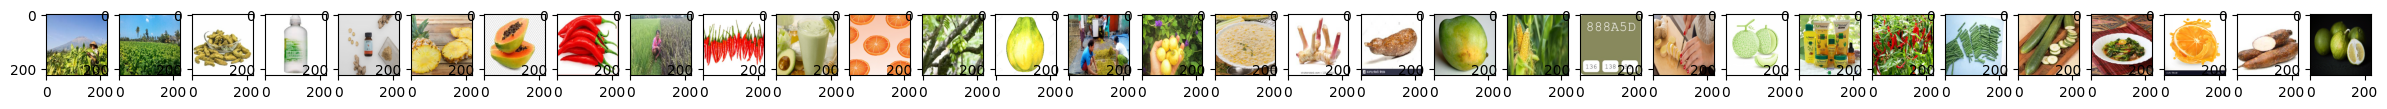

In [8]:
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

images , labels = train_generator[0]

print(images.shape)

plt.figure()
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

In [9]:
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Input,
    Reshape
)

def get_model_compiled():
  model = Sequential()
  model.add(Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

  model.add(Conv2D(16, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(32, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(64, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(128, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Flatten())

  model.add(Dense(30, activation="softmax"))

  model.compile(optimizer="adam",
                loss="categorical_crossentropy",
                metrics=["accuracy"])

  return model

In [10]:
model = get_model_compiled()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │       752,670 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 850,110 (3.24 MB)

 Trainable params: 850,110 (3.24 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow.keras.callbacks import ModelCheckpoint

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Plantalyze

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Plantalyze


In [23]:
current_directory = "/content/drive/MyDrive/Plantalyze"
checkpoint_path = current_directory + "/checkpoints/checkpoint_arq2.weights.h5"
checkpoint = ModelCheckpoint(filepath=checkpoint_path,
                             save_freq= "epoch",
                             save_weights_only = True,
                             verbose = 1)

In [24]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint])

Epoch 1/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4173 - loss: 1.9789
Epoch 1: saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2.weights.h5
657/657 ━━━━━━━━━━━━━━━━━━━━ 72s 110ms/step - accuracy: 0.4408 - loss: 1.9100 - val_accuracy: 0.4887 - val_loss: 1.7781
Epoch 2/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6014 - loss: 1.3561
Epoch 2: saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2.weights.h5
657/657 ━━━━━━━━━━━━━━━━━━━━ 69s 105ms/step - accuracy: 0.6164 - loss: 1.3070 - val_accuracy: 0.5840 - val_loss: 1.5577
Epoch 3/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7640 - loss: 0.7769
Epoch 3: saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2.

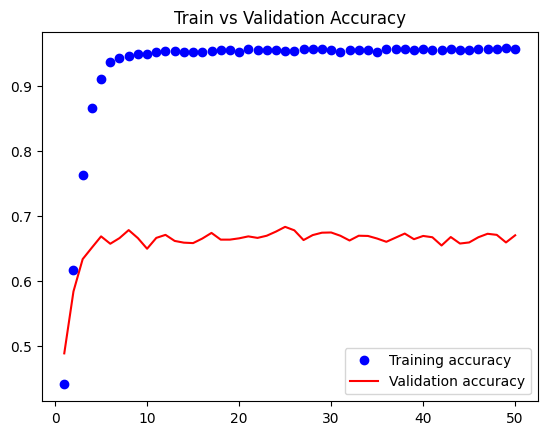

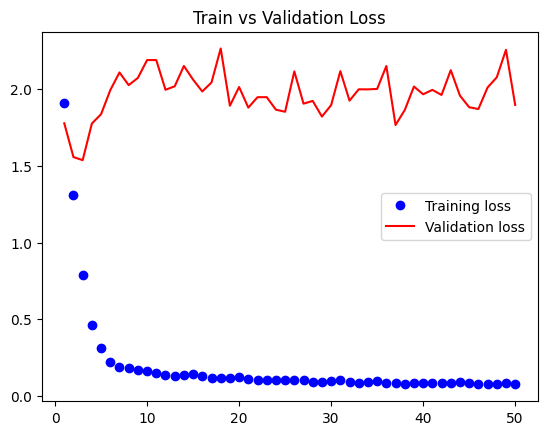

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.plot(epochs_range, acc, "bo", label="Training accuracy")
plt.plot(epochs_range, val_acc, "r", label="Validation accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()

plt.figure()

plt.plot(epochs_range, loss, "bo", label="Training loss")
plt.plot(epochs_range, val_loss, "r", label="Validation loss")
plt.title("Train vs Validation Loss")
plt.legend()

plt.show()

In [26]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

188/188 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - accuracy: 0.6208 - loss: 2.3673
Test accuracy: 0.6208333373069763
Test loss: 2.3672542572021484
188/188 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step


Classification Report:
               precision    recall  f1-score   support

     aloevera       0.74      0.56      0.64       200
       banana       0.50      0.33      0.39       200
      bilimbi       0.58      0.59      0.58       200
   cantaloupe       0.28      0.26      0.27       200
      cassava       0.58      0.68      0.63       200
      coconut       0.61      0.34      0.44       200
         corn       0.55      0.60      0.57       200
     cucumber       0.73      0.67      0.70       200
      curcuma       0.66      0.77      0.71       200
     eggplant       0.70      0.68      0.69       200
     galangal       0.77      0.84      0.80       200
       ginger       0.51      0.64      0.56       200
        guava       0.60      0.62      0.61       200
         kale       0.74      0.59      0.66       200
    longbeans       0.69      0.82      0.75       200
        mango       0.42      0.41      0.41       200
        melon       0.35      0.38      0

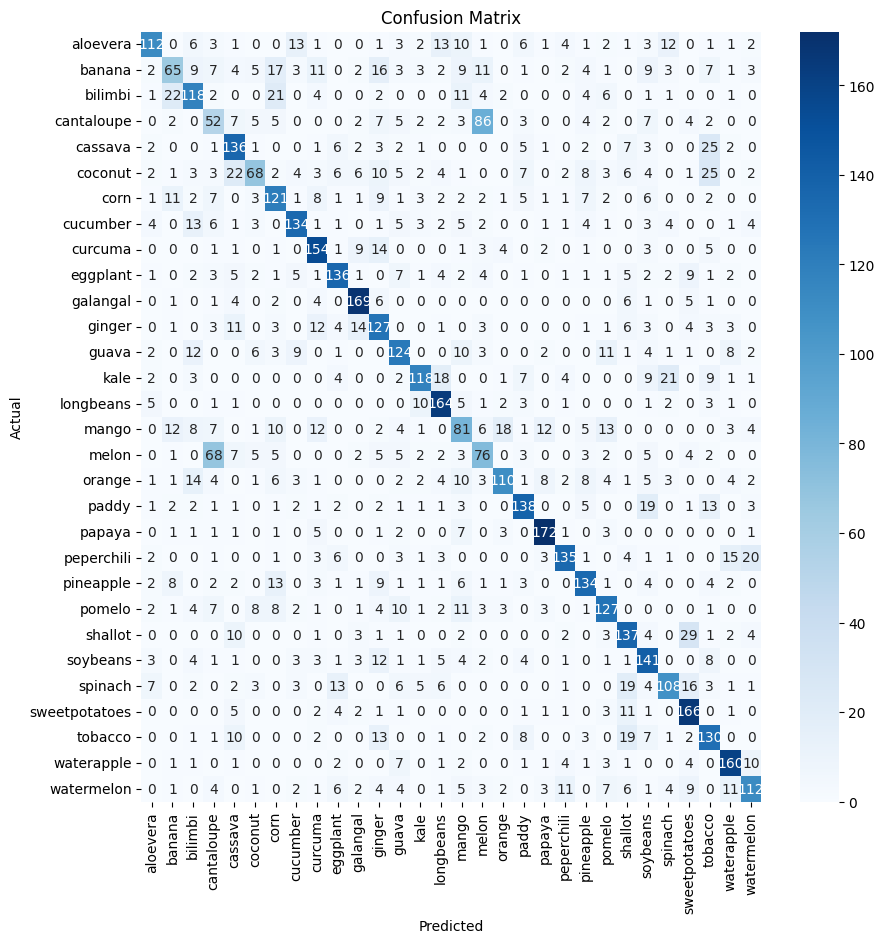

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

class_names = list(test_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
)


conf_matrix = confusion_matrix(y_true, y_pred)

print("Classification Report:")
print(report)

plt.figure(figsize=(10, 10))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
